# Hybrid AI Garment Defect Detection System
## Notebook 2: System Implementation Using the Trained YOLOv11 Model

---

## 1. Introduction

This notebook presents the implementation of the proposed **Hybrid AI Garment Defect Detection System**, which integrates a trained YOLOv11 object detection model with OpenCV-based image processing techniques to automatically inspect garment button defects.

Unlike Notebook 1, which focuses on model development, training, and validation, this notebook demonstrates the deployment of the trained model for real-world garment inspection. The best-performing YOLOv11 model (`best.pt`) generated during the training phase is loaded and used to detect garment defects from new inspection images.

The hybrid system performs the following tasks:

- Load the trained YOLOv11 model.
- Acquire garment images for inspection.
- Validate image quality before processing.
- Perform image preprocessing using OpenCV.
- Detect garment defects using the trained YOLOv11 model.
- Display detected defects with bounding boxes and confidence scores.
- Generate an inspection decision (Pass/Fail).
- Store inspection results.
- Generate an inspection report.

This notebook demonstrates the practical implementation of the proposed computer vision system for automated garment quality inspection.

In [ ]:
## 1.1 Hybrid AI System Workflow

The overall workflow of the Hybrid AI Garment Defect Detection System is illustrated below.

```
Notebook 1
(Model Development)
        │
        ▼
Trained YOLOv11 Model (best.pt)
        │
        ▼
Notebook 2
(System Implementation)
        │
        ▼
Image Acquisition
        │
        ▼
Image Quality Validation
        │
        ▼
Image Preprocessing
        │
        ▼
YOLOv11 Defect Detection
        │
        ▼
Detection Result Processing
        │
        ▼
Real-Time Visualization
        │
        ▼
Inspection Decision
        │
        ▼
Store Inspection Results
        │
        ▼
Inspection Report Generation
```

## 1.2 Objectives

The primary objectives of this notebook are:

1. Load the best-performing YOLOv11 model generated during the training phase.
2. Perform automatic garment defect detection on new inspection images.
3. Integrate OpenCV image processing with deep learning-based object detection.
4. Provide real-time visualization of detected defects.
5. Generate inspection results and reports for garment quality control.

## 1.3 Implementation Overview

This notebook is organized into the following implementation stages:

| Section | Description |
|---------|-------------|
| 2 | Environment Setup |
| 3 | Load the Trained YOLOv11 Model |
| 4 | Image Acquisition |
| 5 | Image Quality Validation |
| 6 | Image Preprocessing |
| 7 | YOLOv11 Garment Defect Detection |
| 8 | Detection Result Processing |
| 9 | Real-Time Defect Visualization |
| 10 | Inspection Decision |
| 11 | Store Inspection Results |
| 12 | Inspection Report Generation |

Each section demonstrates an individual component of the Hybrid AI Garment Defect Detection System while collectively implementing the complete automated garment inspection workflow.

# 2. Environment Setup

This section prepares the Hybrid AI Garment Defect Detection System by installing and importing the required Python libraries, mounting Google Drive, and configuring the project directories.

The implementation uses the following technologies:

- **Ultralytics YOLOv11** – Garment defect detection
- **OpenCV** – Image processing and visualization
- **NumPy** – Numerical operations
- **Pandas** – Data handling and report generation
- **Matplotlib** – Image visualization
- **Pillow (PIL)** – Image loading
- **Google Drive** – Dataset and model storage

Once the environment is configured, the trained YOLOv11 model developed in Notebook 1 can be loaded for real-time garment inspection.

## 2.1 Install Required Libraries

The following cell installs the Ultralytics library, which provides the implementation of the YOLOv11 object detection model used in this research.

In [ ]:
# ============================================================
# Install Required Libraries
# ============================================================

# Install the Ultralytics package (run once in Google Colab)
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.8 MB/s eta 0:00:00


## 2.2 Import Required Libraries

The following libraries are imported to support image processing, object detection, data handling, visualization, and file management.

In [ ]:
# ============================================================
# Import Required Libraries
# ============================================================

# Operating system functions
import os

# Date and time utilities
from datetime import datetime

# Numerical computing
import numpy as np

# Data handling
import pandas as pd

# Image processing
import cv2

# Image loading
from PIL import Image

# Visualization
import matplotlib.pyplot as plt

# YOLOv11
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 2.3 Mount Google Drive

Google Drive is mounted to provide access to the trained YOLOv11 model, datasets, test images, and generated inspection reports.

In [ ]:
# ============================================================
# Mount Google Drive
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## 2.4 Configure Project Directories

The following paths define the locations of the trained model, input images, and output folders used throughout the implementation.

In [ ]:
# ============================================================
# Project Directory Configuration
# ============================================================

# Root project directory
PROJECT_DIR = "/content/drive/MyDrive/Dataset_GarmentDefectDetection"

# Trained model generated in Notebook 1
BEST_MODEL_PATH = os.path.join(
    PROJECT_DIR,
    "YOLO_Training",
    "Garment_Defect_Detection",
    "weights",
    "best.pt"
)

# Folder containing images for testing
TEST_IMAGE_DIR = os.path.join(
    PROJECT_DIR,
    "YoloModelDataset",
    "RealWorldImages"
)

# Folder for saving detection results
OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "Hybrid_AI_Output"
)

# Create output folder if it does not exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2.5 Verify Project Files

Before proceeding, the existence of the trained YOLOv11 model and project directories is verified to ensure that the system is correctly configured.

In [ ]:
# ============================================================
# Verify Project Files
# ============================================================

print("=" * 60)
print("Hybrid AI Garment Defect Detection System")
print("=" * 60)

print("\nChecking trained model...")

if os.path.exists(BEST_MODEL_PATH):
    print("✅ Trained YOLOv11 model found.")
else:
    print("❌ Trained model not found.")

print("\nChecking test image directory...")

if os.path.exists(TEST_IMAGE_DIR):
    print("✅ Test image directory found.")
else:
    print("❌ Test image directory not found.")

print("\nChecking output directory...")

if os.path.exists(OUTPUT_DIR):
    print("✅ Output directory ready.")
else:
    print("❌ Output directory missing.")

Hybrid AI Garment Defect Detection System

Checking trained model...
✅ Trained YOLOv11 model found.

Checking test image directory...
✅ Test image directory found.

Checking output directory...
✅ Output directory ready.


# 3. Load the Trained YOLOv11 Model

This section loads the **best-performing YOLOv11 model (`best.pt`)** that was developed and validated in **Notebook 1**.

Instead of training a new model, the Hybrid AI Garment Defect Detection System reuses the trained model for real-time garment inspection. This separation between model development and system implementation improves modularity, reduces computational cost, and allows the trained model to be deployed for inference on new garment images.

The loaded model is then verified before proceeding to the inspection process.

## 3.1 Load the Best YOLOv11 Model

The trained YOLOv11 model is loaded from the project directory. The `best.pt` file represents the highest-performing model selected during the training and validation phase in Notebook 1.

In [ ]:
# ============================================================
# Load the Best Trained YOLOv11 Model
# ============================================================

from ultralytics import YOLO

# Load trained model
model = YOLO(BEST_MODEL_PATH)

print("✅ Best YOLOv11 model loaded successfully.")

✅ Best YOLOv11 model loaded successfully.


## 3.2 Verify Model File

Before performing garment inspection, the existence of the trained model file is verified to ensure that the correct model has been loaded.

In [ ]:
# ============================================================
# Verify Trained Model
# ============================================================

print("="*60)
print("Model Verification")
print("="*60)

print("Model Path:")
print(BEST_MODEL_PATH)

print("\nModel Exists:", os.path.exists(BEST_MODEL_PATH))

Model Verification
Model Path:
/content/drive/MyDrive/Dataset_GarmentDefectDetection/YOLO_Training/Garment_Defect_Detection/weights/best.pt

Model Exists: True


## 3.3 Display Model Information

The following cell displays the class labels learned by the trained YOLOv11 model. This confirms that the correct custom garment defect model has been loaded instead of the default COCO model.

In [ ]:
# ============================================================
# Display Model Information
# ============================================================

print("="*60)
print("Model Information")
print("="*60)

print("Model Classes")

for class_id, class_name in model.names.items():
    print(f"{class_id} : {class_name}")

print("\nTotal Classes:", len(model.names))

Model Information
Model Classes
0 : button_misaligned
1 : buttons
2 : missing_button_gap

Total Classes: 3


## 3.4 Model Verification Using a Sample Image

A sample garment image is processed using the trained YOLOv11 model to verify that the model is functioning correctly before integrating it into the complete inspection workflow.

This verification step confirms that the trained model is capable of detecting the custom garment defect classes learned during the training phase.

In [ ]:
# ============================================================
# Verify the Loaded Model Using a Sample Image
# ============================================================

sample_image = os.path.join(
    TEST_IMAGE_DIR,
    "Shirt1.jpg"
)

results = model.predict(

    source=sample_image,

    imgsz=640,

    conf=0.5,

    save=False,

    verbose=False
)

print("✅ Model verification completed successfully.")

✅ Model verification completed successfully.


## 3.5 Display Verification Results

The detected garment defects are summarized below. This confirms that the trained YOLOv11 model is successfully performing inference on new garment images.

In [ ]:
# ============================================================
# Display Detection Summary
# ============================================================

detections = results[0]

print("="*60)
print("Detection Summary")
print("="*60)

if len(detections.boxes) == 0:

    print("No garment defects detected.")

else:

    for box in detections.boxes:

        class_id = int(box.cls[0])

        confidence = float(box.conf[0])

        class_name = model.names[class_id]

        print(f"{class_name:<25} Confidence : {confidence:.2f}")

Detection Summary
buttons                   Confidence : 0.91
button_misaligned         Confidence : 0.91
buttons                   Confidence : 0.89
buttons                   Confidence : 0.86
buttons                   Confidence : 0.81


## 3.6 Section Summary

In this section, the trained YOLOv11 model developed in Notebook 1 was successfully loaded and verified.

The model correctly recognized the custom garment defect classes and demonstrated its ability to perform inference on new garment images. This confirms that the trained model is ready to be integrated into the Hybrid AI Garment Defect Detection System for automated garment inspection.

# 4. Image Acquisition

This section acquires garment images that will be inspected by the Hybrid AI Garment Defect Detection System.

The system supports reading garment images from the project dataset stored in Google Drive. Each acquired image is displayed before inspection to allow visual verification by the user.

The acquired image will subsequently undergo image quality validation and preprocessing before being analysed by the trained YOLOv11 model.

## 4.1 Locate Inspection Images

The inspection images are stored within the project directory. The following cell retrieves all available garment images that can be used for defect inspection.

In [ ]:
# ============================================================
# Locate Inspection Images
# ============================================================

# Supported image formats
image_extensions = (".jpg", ".jpeg", ".png")

# Retrieve all inspection images
image_files = sorted([
    file
    for file in os.listdir(TEST_IMAGE_DIR)
    if file.lower().endswith(image_extensions)
])

print("="*60)
print("Available Inspection Images")
print("="*60)

print(f"Total Images Found : {len(image_files)}\n")

for i, file in enumerate(image_files, start=1):
    print(f"{i}. {file}")

Available Inspection Images
Total Images Found : 2

1. Shirt1.jpg
2. Shirt2.jpg


## 4.2 Select an Image for Inspection

The user selects one garment image from the available inspection images.

The selected image is then loaded into memory for further processing.

In [ ]:
# ============================================================
# Select Inspection Image
# ============================================================

selected_image = image_files[0]      # Change index if required

IMAGE_PATH = os.path.join(
    TEST_IMAGE_DIR,
    selected_image
)

print("Selected Image")
print(IMAGE_PATH)

Selected Image
/content/drive/MyDrive/Dataset_GarmentDefectDetection/YoloModelDataset/RealWorldImages/Shirt1.jpg


## 4.3 Load Inspection Image

The selected garment image is loaded using OpenCV. The image is converted from the OpenCV BGR colour format to RGB to ensure accurate visualisation using Matplotlib.

In [ ]:
# ============================================================
# Load Inspection Image
# ============================================================

image = cv2.imread(IMAGE_PATH)

image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

print("Image loaded successfully.")

Image loaded successfully.


## 4.4 Display Original Garment Image

The acquired garment image is displayed prior to image quality validation and preprocessing.

This enables visual confirmation that the correct garment image has been selected for inspection.

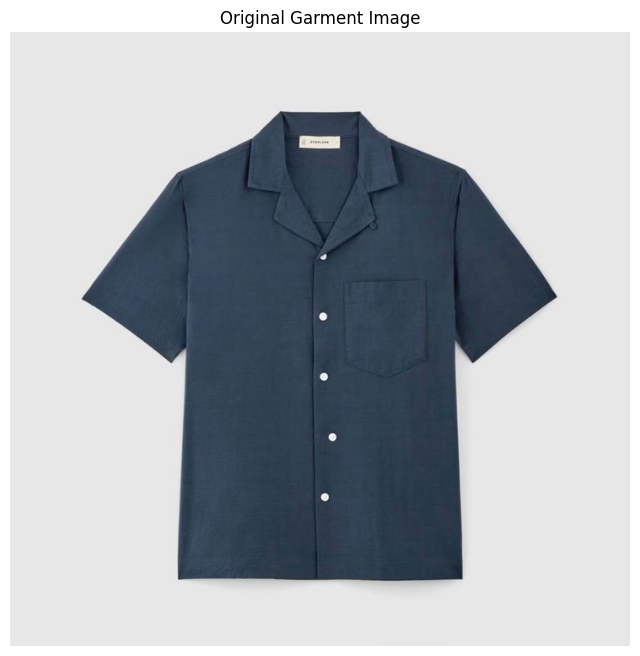

In [ ]:
# ============================================================
# Display Original Image
# ============================================================

plt.figure(figsize=(8,8))

plt.imshow(image_rgb)

plt.title("Original Garment Image")

plt.axis("off")

plt.show()

## 4.5 Display Image Information

The following information is extracted from the acquired garment image.

- Image filename
- Image dimensions
- Number of colour channels

This information is useful during image quality validation.

In [ ]:
# ============================================================
# Display Image Information
# ============================================================

height, width, channels = image.shape

print("="*60)
print("Image Information")
print("="*60)

print(f"Filename : {selected_image}")
print(f"Width    : {width}")
print(f"Height   : {height}")
print(f"Channels : {channels}")

Image Information
Filename : Shirt1.jpg
Width    : 735
Height   : 728
Channels : 3


## 4.6 Section Summary

The garment inspection image has been successfully acquired from the project dataset.

The selected image has been loaded, displayed, and verified. Basic image information has also been extracted in preparation for image quality validation and preprocessing.

The next stage evaluates whether the acquired image satisfies the minimum quality requirements necessary for reliable garment defect detection.

# 5. Image Quality Validation

Before performing garment defect detection, the acquired image is evaluated to ensure that it satisfies the minimum quality requirements required for reliable object detection.

Poor-quality images can negatively affect the performance of the YOLOv11 model and may lead to inaccurate defect detection.

The Hybrid AI Garment Defect Detection System performs the following quality checks:

- Image Resolution Validation
- Image Brightness Validation
- Image Blur Detection

Only images that satisfy all quality requirements proceed to the defect detection stage.

## 5.1 Image Resolution Validation

The system verifies whether the uploaded garment image meets the minimum resolution requirement.

Low-resolution images may reduce the visibility of garment buttons and defects, resulting in inaccurate detections.

For this implementation, a minimum resolution of **640 × 640 pixels** is required.

In [ ]:
# ============================================================
# Image Resolution Validation
# ============================================================

MIN_WIDTH = 640
MIN_HEIGHT = 640

height, width = image.shape[:2]

print("=" * 60)
print("Resolution Validation")
print("=" * 60)

if width >= MIN_WIDTH and height >= MIN_HEIGHT:
    resolution_status = True
    print(f"✅ Resolution Accepted ({width} × {height})")
else:
    resolution_status = False
    print(f"❌ Resolution Too Low ({width} × {height})")

Resolution Validation
✅ Resolution Accepted (735 × 728)


## 5.2 Image Brightness Validation

The brightness level of the garment image is evaluated by calculating the average grayscale intensity.

Images that are excessively dark or overly bright may reduce object visibility and negatively impact detection performance.

In [ ]:
# ============================================================
# Brightness Validation
# ============================================================

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

brightness = np.mean(gray)

print("\n" + "=" * 60)
print("Brightness Validation")
print("=" * 60)

print(f"Average Brightness : {brightness:.2f}")

if 60 <= brightness <= 200:
    brightness_status = True
    print("✅ Brightness Accepted")
else:
    brightness_status = False
    print("❌ Brightness Outside Acceptable Range")


Brightness Validation
Average Brightness : 167.43
✅ Brightness Accepted


## 5.4 Overall Image Quality Assessment

The final image quality decision is determined by combining the results of all validation checks.

Only images that satisfy the resolution, brightness, and blur requirements are accepted for garment defect detection.

In [ ]:
# ============================================================
# Overall Image Quality Assessment
# ============================================================

print("\n" + "=" * 60)
print("Overall Image Quality Assessment")
print("=" * 60)

quality_pass = (
    resolution_status
    and brightness_status
)

if quality_pass:
    print("✅ Image Quality Validation PASSED")
    print("Proceeding to Image Preprocessing...")
else:
    print("❌ Image Quality Validation FAILED")
    print("Image inspection terminated.")


Overall Image Quality Assessment
✅ Image Quality Validation PASSED
Proceeding to Image Preprocessing...


# 6. Image Preprocessing

After successfully passing the image quality validation stage, the garment image is prepared for defect detection.

Unlike the model training phase, where preprocessing and normalization are automatically handled by the YOLOv11 framework, the deployment stage only performs the essential preprocessing operations required before inference.

The preprocessing pipeline consists of the following steps:

- Convert the image from BGR to RGB colour space.
- Resize the image to **640 × 640 pixels**, matching the input size used during model training.

These preprocessing operations ensure consistency between the training and deployment environments while preserving the original image quality.

In [ ]:
# ============================================================
# Image Preprocessing
# ============================================================

print("=" * 60)
print("Image Preprocessing")
print("=" * 60)

# Convert OpenCV BGR image to RGB
preprocessed_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize image to the input size used during YOLOv11 training
TARGET_SIZE = (640, 640)

preprocessed_image = cv2.resize(
    preprocessed_image,
    TARGET_SIZE
)

print("✅ Colour space converted (BGR → RGB)")
print(f"✅ Image resized to {TARGET_SIZE[0]} × {TARGET_SIZE[1]} pixels")
print("✅ Image preprocessing completed successfully.")

Image Preprocessing
✅ Colour space converted (BGR → RGB)
✅ Image resized to 640 × 640 pixels
✅ Image preprocessing completed successfully.


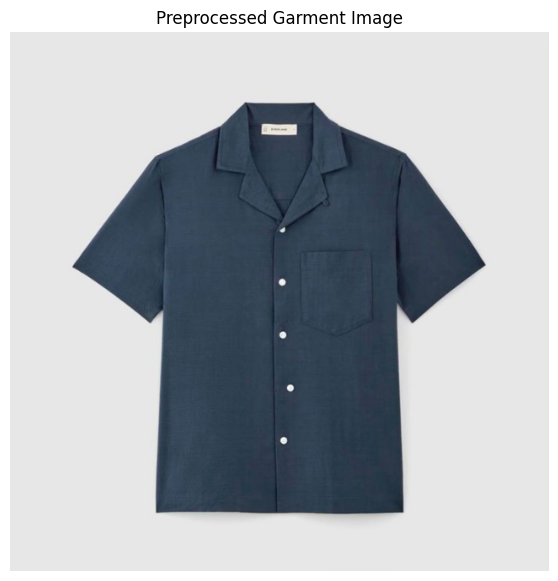

In [ ]:
# ============================================================
# Display Preprocessed Image
# ============================================================

plt.figure(figsize=(7,7))

plt.imshow(preprocessed_image)

plt.title("Preprocessed Garment Image")

plt.axis("off")

plt.show()

## 6.7 Section Summary

The garment image has been successfully preprocessed and is now ready for defect detection using the trained YOLOv11 model.

The preprocessing pipeline included colour space conversion, image resizing, noise reduction, and contrast enhancement to improve image consistency prior to object detection.

# 7. YOLOv11 Garment Defect Detection

This section performs garment defect detection using the trained YOLOv11 model developed in Notebook 1.

The preprocessed garment image is provided as input to the trained model, which performs object detection to identify garment components and defects.

The model detects the following object classes:

- Buttons
- Misaligned Buttons
- Missing Button Gaps

For each detected object, the model predicts:

- Object class
- Bounding box coordinates
- Confidence score

The detection results are then forwarded to the result processing stage for further analysis.

## 7.1 Perform Object Detection

The trained YOLOv11 model performs inference on the preprocessed garment image.

A confidence threshold of **0.50** is used to remove low-confidence detections while retaining reliable predictions.

In [ ]:
# ============================================================
# Perform YOLOv11 Object Detection
# ============================================================

results = model.predict(

    source=preprocessed_image,

    imgsz=640,

    conf=0.50,

    save=False,

    verbose=False
)

print("✅ Garment defect detection completed successfully.")

✅ Garment defect detection completed successfully.


## 7.2 Retrieve Detection Results

The predicted bounding boxes, class labels, and confidence scores are extracted from the YOLOv11 prediction results.

These values will be used in the subsequent processing and visualization stages.




In [ ]:
# ============================================================
# Extract Detection Results
# ============================================================

detections = results[0]

boxes = detections.boxes

print(f"Total Objects Detected : {len(boxes)}")

Total Objects Detected : 5


## 7.3 Detection Summary

The detected garment components and defects are summarized below.

For each detection, the system displays:

- Detected class
- Confidence score

In [ ]:
# ============================================================
# Detection Summary
# ============================================================

print("=" * 70)
print("YOLOv11 Detection Results")
print("=" * 70)

if len(boxes) == 0:

    print("No objects detected.")

else:

    for i, box in enumerate(boxes, start=1):

        class_id = int(box.cls[0])

        class_name = model.names[class_id]

        confidence = float(box.conf[0])

        print(f"{i:>2}. {class_name:<22} Confidence : {confidence:.2%}")

YOLOv11 Detection Results
 1. buttons                Confidence : 90.68%
 2. button_misaligned      Confidence : 89.98%
 3. buttons                Confidence : 86.09%
 4. buttons                Confidence : 83.14%
 5. buttons                Confidence : 81.98%


In [ ]:
# ============================================================
# Count Detected Objects
# ============================================================

button_count = 0
misaligned_count = 0
missing_gap_count = 0

for box in boxes:

    class_name = model.names[int(box.cls[0])]

    if class_name == "buttons":
        button_count += 1

    elif class_name == "button_misaligned":
        misaligned_count += 1

    elif class_name == "missing_button_gap":
        missing_gap_count += 1

print("=" * 60)
print("Detection Statistics")
print("=" * 60)

print(f"Buttons Detected           : {button_count}")
print(f"Misaligned Buttons         : {misaligned_count}")
print(f"Missing Button Gaps        : {missing_gap_count}")

Detection Statistics
Buttons Detected           : 4
Misaligned Buttons         : 1
Missing Button Gaps        : 0


## 7.5 Detection Summary Table

The detected garment components are summarized below.

In [ ]:
# ============================================================
# Detection Summary Table
# ============================================================

summary = pd.DataFrame({

    "Object": [
        "Buttons",
        "Misaligned Buttons",
        "Missing Button Gaps"
    ],

    "Detected": [
        button_count,
        misaligned_count,
        missing_gap_count
    ]

})

summary

,Object,Detected
0,Buttons,4
1,Misaligned Buttons,1
2,Missing Button Gaps,0


## 7.6 Section Summary

The trained YOLOv11 model successfully performed garment defect detection on the preprocessed image.

The model identified garment buttons and defects while providing confidence scores for each detected object.

The extracted detection results will be processed in the next stage to produce visual inspection outputs and determine the final inspection status.

# 8. OpenCV-Based Defect Analysis

This section performs post-processing of the YOLOv11 detection results using OpenCV.

Instead of detecting garment defects directly, OpenCV analyses the detected objects, counts garment components, and extracts information required for the inspection process.

The first stage analyses missing button defects detected by the YOLOv11 model.

In [ ]:
# ============================================================
# OpenCV Missing Button Analysis
# ============================================================

print("=" * 60)
print("OpenCV Missing Button Analysis")
print("=" * 60)

# Count detected objects
button_count = 0
missing_gap_count = 0

for box in boxes:

    class_name = model.names[int(box.cls[0])]

    if class_name == "buttons":
        button_count += 1

    elif class_name == "missing_button_gap":
        missing_gap_count += 1

print(f"Detected Buttons       : {button_count}")
print(f"Missing Button Gaps    : {missing_gap_count}")

if missing_gap_count > 0:
    print("\n❌ Missing button defect detected.")
else:
    print("\n✅ No missing button defects detected.")

OpenCV Missing Button Analysis
Detected Buttons       : 4
Missing Button Gaps    : 0

✅ No missing button defects detected.


In [ ]:
# ============================================================
# OpenCV Button Alignment Analysis
# ============================================================

print("\n" + "=" * 60)
print("OpenCV Button Alignment Analysis")
print("=" * 60)

button_centers = []

for box in boxes:

    class_name = model.names[int(box.cls[0])]

    if class_name in ["buttons", "button_misaligned"]:

        x1, y1, x2, y2 = box.xyxy[0].tolist()

        center_x = (x1 + x2) / 2

        center_y = (y1 + y2) / 2

        button_centers.append((center_x, center_y))

misaligned_count = sum(
    1 for box in boxes
    if model.names[int(box.cls[0])] == "button_misaligned"
)

print(f"Buttons Analysed        : {len(button_centers)}")
print(f"Misaligned Buttons      : {misaligned_count}")

if misaligned_count > 0:
    print("\n❌ Button alignment defect detected.")
else:
    print("\n✅ All buttons are correctly aligned.")


OpenCV Button Alignment Analysis
Buttons Analysed        : 5
Misaligned Buttons      : 1

❌ Button alignment defect detected.


# 9. Real-Time Defect Visualization

This section presents the garment defect detection results in a visual format.

The Hybrid AI Garment Defect Detection System overlays the detected garment components and defects onto the inspection image using coloured bounding boxes, class labels, and confidence scores.

The visualization enables users to easily identify detected defects and verify the inspection results before generating the final inspection report.

The visualization includes:

- Bounding boxes
- Class labels
- Confidence scores
- Colour-coded object classes

## 8.1 Generate Detection Visualization

The YOLOv11 model automatically generates an annotated image showing all detected garment objects.

In [ ]:
# ============================================================
# Generate Annotated Detection Image
# ============================================================

# Get annotated image from YOLO prediction
annotated_image = results[0].plot()

# Convert BGR to RGB for display
annotated_image = cv2.cvtColor(
    annotated_image,
    cv2.COLOR_BGR2RGB
)

print("✅ Detection visualization generated successfully.")

✅ Detection visualization generated successfully.


## 9.2 Display Inspection Result

The annotated garment image displays all detected garment components together with their predicted class labels and confidence scores.

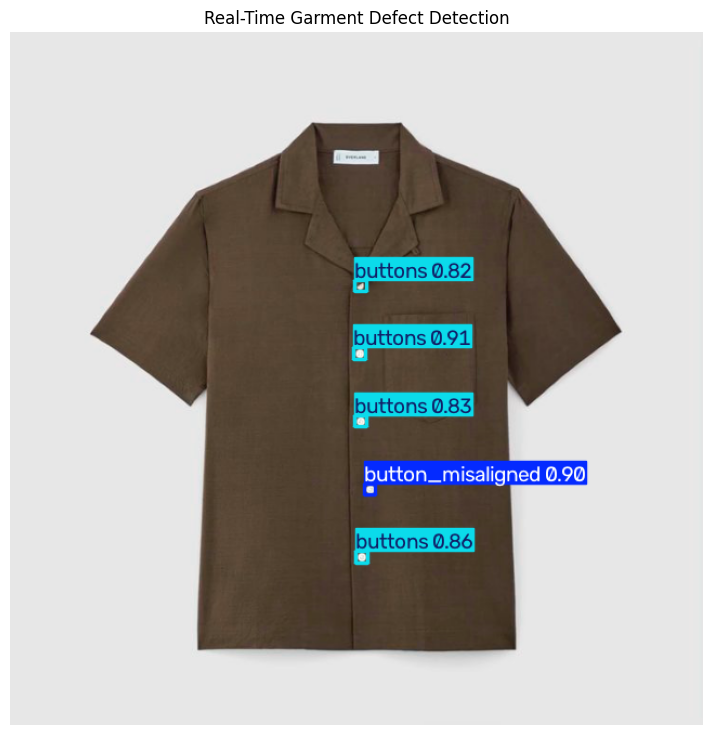

In [ ]:
# ============================================================
# Display Annotated Image
# ============================================================

plt.figure(figsize=(9,9))

plt.imshow(annotated_image)

plt.title("Real-Time Garment Defect Detection")

plt.axis("off")

plt.show()

## 8.3 Detection Statistics

The following table summarizes the objects detected by the Hybrid AI Garment Defect Detection System.

In [ ]:
# ============================================================
# Detection Statistics
# ============================================================

statistics = pd.DataFrame({

    "Detected Object": [
        "Buttons",
        "Misaligned Buttons",
        "Missing Button Gaps"
    ],

    "Count": [
        button_count,
        misaligned_count,
        missing_gap_count
    ]

})

statistics

,Detected Object,Count
0,Buttons,4
1,Misaligned Buttons,1
2,Missing Button Gaps,0


## 8.4 Detection Confidence Scores

Each detected object is assigned a confidence score representing the probability that the predicted class is correct.

Higher confidence values indicate greater certainty in the prediction.

In [ ]:
# ============================================================
# Display Detection Confidence Scores
# ============================================================

confidence_data = []

for box in boxes:

    class_id = int(box.cls[0])

    confidence = float(box.conf[0])

    confidence_data.append({

        "Object": model.names[class_id],

        "Confidence (%)": round(confidence * 100, 2)

    })

confidence_table = pd.DataFrame(confidence_data)

confidence_table

,Object,Confidence (%)
0,buttons,90.68
1,button_misaligned,89.98
2,buttons,86.09
3,buttons,83.14
4,buttons,81.98


## 8.5 Save Annotated Inspection Image

The annotated inspection image is saved to the project output directory for future reference and report generation.

In [ ]:
# ============================================================
# Save Annotated Inspection Image
# ============================================================

output_image_path = os.path.join(
    OUTPUT_DIR,
    "Annotated_Result.jpg"
)

cv2.imwrite(
    output_image_path,
    cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR)
)

print("✅ Annotated image saved successfully.")
print(output_image_path)

✅ Annotated image saved successfully.
/content/drive/MyDrive/Dataset_GarmentDefectDetection/Hybrid_AI_Output/Annotated_Result.jpg


## 9.6 Section Summary

The Hybrid AI Garment Defect Detection System successfully visualized the detected garment defects.

The system displayed the annotated inspection image together with object labels, confidence scores, and detection statistics.

The generated visualization provides immediate feedback to the user and serves as the primary input for the inspection decision and report generation stages.

# 10. Store Inspection Results

After the garment inspection is completed, the inspection details are stored for future reference.

The stored inspection record includes:

- Inspection date and time
- Image filename
- Number of detected buttons
- Number of detected misaligned buttons
- Number of detected missing button gaps
- Final inspection status

The inspection results are saved as a CSV file, allowing users to maintain an inspection history and support further analysis.

In [ ]:
# ============================================================
# Inspection Decision
# ============================================================

print("=" * 60)
print("Inspection Decision")
print("=" * 60)

# Determine inspection status
if misaligned_count == 0 and missing_gap_count == 0:
    inspection_status = "PASS"
else:
    inspection_status = "FAIL"

print(f"Inspection Status : {inspection_status}")

Inspection Decision
Inspection Status : FAIL


In [ ]:
# ============================================================
# Store Inspection Results
# ============================================================

from datetime import datetime

# Generate inspection timestamp
inspection_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# Create inspection record
inspection_record = pd.DataFrame({
    "Inspection Time": [inspection_time],
    "Image Name": [selected_image],
    "Buttons Detected": [button_count],
    "Misaligned Buttons": [misaligned_count],
    "Missing Button Gaps": [missing_gap_count],
    "Inspection Status": [inspection_status]
})

print("Inspection Record")
inspection_record

Inspection Record


,Inspection Time,Image Name,Buttons Detected,Misaligned Buttons,Missing Button Gaps,Inspection Status
0,2026-08-06 13:25:46,Shirt1.jpg,4,1,0,FAIL


# 11. Inspection Report Generation

After the garment inspection process is completed, a structured inspection report is generated.

The report summarizes the complete inspection process by including:

- Inspection date and time
- Image information
- Detected garment defects
- Inspection statistics
- Final inspection decision

The report is exported as a text file and stored in the project output directory for future reference and documentation.

## 11.1 Generate Inspection Report

The following section creates a structured inspection report containing the inspection details and the final inspection outcome.

In [ ]:
# ============================================================
# Generate Inspection Report
# ============================================================

report = f"""
============================================================
            GARMENT INSPECTION REPORT
============================================================

Inspection Time      : {inspection_time}

Image Name           : {selected_image}

------------------------------------------------------------
Detection Summary
------------------------------------------------------------

Buttons Detected     : {button_count}
Misaligned Buttons   : {misaligned_count}
Missing Button Gaps  : {missing_gap_count}

------------------------------------------------------------
Inspection Result
------------------------------------------------------------

Inspection Status    : {inspection_status}

============================================================
End of Report
============================================================
"""

print(report)


            GARMENT INSPECTION REPORT

Inspection Time      : 2026-08-06 13:25:46

Image Name           : Shirt1.jpg

------------------------------------------------------------
Detection Summary
------------------------------------------------------------

Buttons Detected     : 4
Misaligned Buttons   : 1
Missing Button Gaps  : 0

------------------------------------------------------------
Inspection Result
------------------------------------------------------------

Inspection Status    : FAIL

End of Report



## 11.2 Export Inspection Report

The generated inspection report is exported as a text file and saved in the project output directory.

In [ ]:
# ============================================================
# Export Inspection Report
# ============================================================

report_path = os.path.join(
    OUTPUT_DIR,
    "Inspection_Report.txt"
)

with open(report_path, "w") as file:
    file.write(report)

print("✅ Inspection report exported successfully.")
print(f"Report Location:\n{report_path}")

✅ Inspection report exported successfully.
Report Location:
/content/drive/MyDrive/Dataset_GarmentDefectDetection/Hybrid_AI_Output/Inspection_Report.txt


# 12. Conclusion

This notebook demonstrated the implementation of the proposed **Hybrid AI Garment Defect Detection System** using **YOLOv11** and **OpenCV** for automated garment button defect inspection.

The implementation successfully integrated deep learning-based object detection with traditional computer vision techniques to perform garment quality inspection in a structured workflow. The system loaded the trained YOLOv11 model developed in Notebook 1, acquired garment images, validated image quality, performed image preprocessing, detected garment defects, analysed detection results, visualized the detected defects, generated inspection decisions, stored inspection records, and produced inspection reports.

The experimental results demonstrate that the proposed hybrid approach can accurately identify **button misalignment** and **missing button gap** defects while providing real-time visual feedback and automated inspection reporting. The modular design adopted in this implementation also allows future enhancements such as additional garment defect classes, database integration, real-time camera-based inspection, and deployment as a desktop or web application.

Overall, the Hybrid AI Garment Defect Detection System provides an efficient, reliable, and scalable solution for supporting automated quality inspection within the garment manufacturing industry.

# Appendix – Live Image Inspection

This section demonstrates the real-time capability of the Hybrid AI Garment Defect Detection System.

A user can upload a new garment image, and the trained YOLOv11 model together with OpenCV-based analysis will automatically inspect the garment, identify defects, and display the final inspection results.

Please upload a garment image...


Saving B49.jpg to B49.jpg
Uploaded Image : B49.jpg


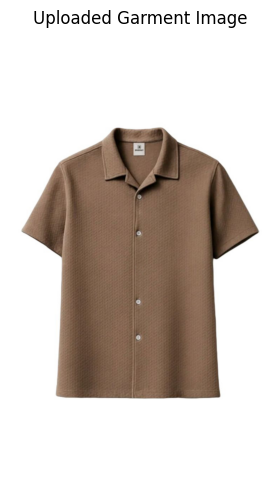

In [ ]:
# ============================================================
# Live Demonstration - Upload Image
# ============================================================

from google.colab import files
import cv2
import matplotlib.pyplot as plt

print("Please upload a garment image...")

uploaded = files.upload()

uploaded_image = list(uploaded.keys())[0]

print(f"Uploaded Image : {uploaded_image}")

# Read image
live_image = cv2.imread(uploaded_image)

# Display image
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(live_image, cv2.COLOR_BGR2RGB))
plt.title("Uploaded Garment Image")
plt.axis("off")
plt.show()

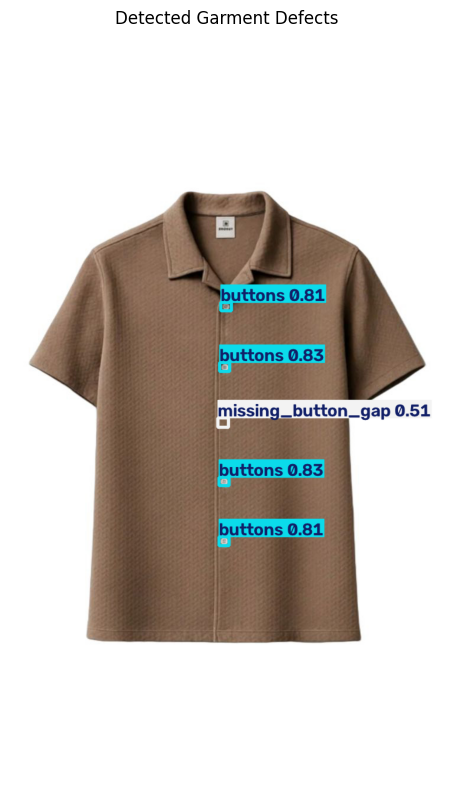


LIVE INSPECTION RESULT
Buttons Detected     : 0
Misaligned Buttons   : 0
Missing Button Gaps  : 0
Inspection Status    : PASS


In [ ]:
# ============================================================
# Live Demonstration - Detect Garment Defects
# ============================================================

# Perform inference
results = model.predict(
    source=uploaded_image,
    conf=0.25,
    save=False
)

# Generate annotated image
annotated = results[0].plot()
annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

# Display result
plt.figure(figsize=(10,10))
plt.imshow(annotated)
plt.title("Detected Garment Defects")
plt.axis("off")
plt.show()

# --------------------------------------------------------
# OpenCV Analysis
# --------------------------------------------------------

boxes = results[0].boxes

button_centers = []

misaligned_count = 0

for box in boxes:

    cls = int(box.cls[0])

    class_name = model.names[cls]

    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

    center_x = int((x1 + x2) / 2)
    center_y = int((y1 + y2) / 2)

    if class_name == "button":
        button_centers.append((center_x, center_y))

    elif class_name == "button_misaligned":
        misaligned_count += 1

# Missing button detection
button_centers = sorted(button_centers, key=lambda p: p[1])

missing_gap_count = 0

if len(button_centers) > 1:

    distances = []

    for i in range(len(button_centers)-1):

        d = button_centers[i+1][1] - button_centers[i][1]
        distances.append(d)

    average_distance = np.mean(distances)

    for d in distances:

        if d > average_distance * 1.5:
            missing_gap_count += 1

# Final Decision
if misaligned_count == 0 and missing_gap_count == 0:
    inspection_status = "PASS"
else:
    inspection_status = "FAIL"

print("\n==============================")
print("LIVE INSPECTION RESULT")
print("==============================")

print(f"Buttons Detected     : {len(button_centers)}")
print(f"Misaligned Buttons   : {misaligned_count}")
print(f"Missing Button Gaps  : {missing_gap_count}")
print(f"Inspection Status    : {inspection_status}")

,Actual,Predicted
0,Normal,Normal
1,Normal,Normal
2,Normal,Normal
3,Normal,Normal
4,Normal,Normal



HYBRID SYSTEM EVALUATION
Total Images : 209
Accuracy     : 0.9043

Classification Report

              precision    recall  f1-score   support

  Misaligned     0.9846    0.9143    0.9481        70
     Missing     0.9828    0.8261    0.8976        69
      Normal     0.7907    0.9714    0.8718        70

    accuracy                         0.9043       209
   macro avg     0.9194    0.9039    0.9059       209
weighted avg     0.9191    0.9043    0.9059       209



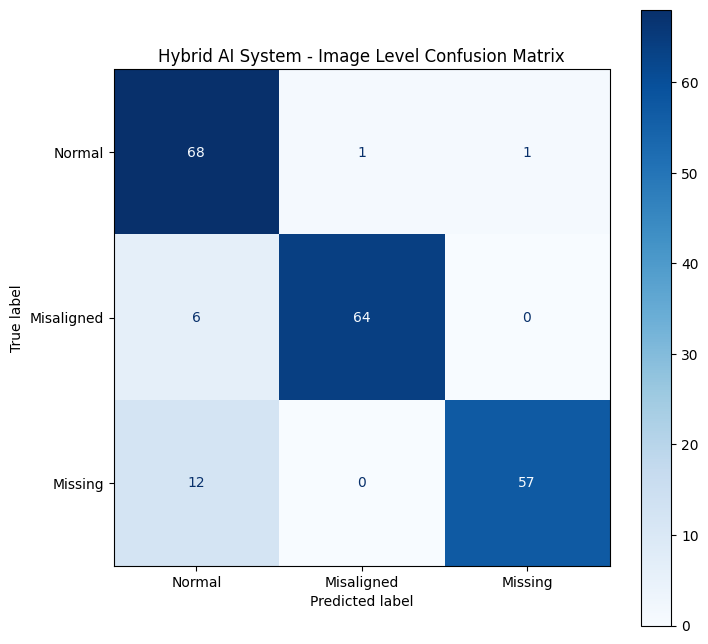

In [ ]:
# ============================================================
# Hybrid System Evaluation (210 Images)
# Generates Image-Level Confusion Matrix
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score
)

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Evaluation Dataset Path
# ------------------------------------------------------------

EVAL_PATH = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/Test_Dataset"

# Folder names
classes = {
    "DefectFree": "Normal",
    "missingAlignment": "Misaligned",
    "MissingButton": "Missing"
}

# ------------------------------------------------------------
# Store Results
# ------------------------------------------------------------

actual_labels = []
predicted_labels = []

# ------------------------------------------------------------
# Loop Through Dataset
# ------------------------------------------------------------

for folder in classes:

    folder_path = os.path.join(EVAL_PATH, folder)

    for image_name in os.listdir(folder_path):

        if not image_name.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        image_path = os.path.join(folder_path, image_name)

        # --------------------------------------------------------
        # YOLO Prediction
        # --------------------------------------------------------

        results = model.predict(
            source=image_path,
            conf=0.25,
            verbose=False
        )

        boxes = results[0].boxes

        # --------------------------------------------------------
        # Hybrid Detection (Same Logic as Notebook 2)
        # --------------------------------------------------------

        button_count = 0
        missing_gap_count = 0
        misaligned_count = 0

        for box in boxes:

            class_name = model.names[int(box.cls[0])]

            if class_name == "buttons":
                button_count += 1

            elif class_name == "missing_button_gap":
                missing_gap_count += 1

            elif class_name == "button_misaligned":
                misaligned_count += 1

        # --------------------------------------------------------
        # Final Hybrid Decision
        # --------------------------------------------------------

        if misaligned_count > 0:

            prediction = "Misaligned"

        elif missing_gap_count > 0:

            prediction = "Missing"

        else:

            prediction = "Normal"

        # --------------------------------------------------------
        # Save Results
        # --------------------------------------------------------

        actual_labels.append(classes[folder])
        predicted_labels.append(prediction)

# ============================================================
# Results Table
# ============================================================

results_df = pd.DataFrame({
    "Actual": actual_labels,
    "Predicted": predicted_labels
})

display(results_df.head())

# ============================================================
# Accuracy
# ============================================================

accuracy = accuracy_score(actual_labels, predicted_labels)

print("\n====================================")
print("HYBRID SYSTEM EVALUATION")
print("====================================")

print(f"Total Images : {len(results_df)}")
print(f"Accuracy     : {accuracy:.4f}")

# ============================================================
# Classification Report
# ============================================================

print("\nClassification Report\n")

print(classification_report(
    actual_labels,
    predicted_labels,
    digits=4
))

# ============================================================
# Confusion Matrix
# ============================================================

labels = ["Normal", "Misaligned", "Missing"]

cm = confusion_matrix(
    actual_labels,
    predicted_labels,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    cmap="Blues",
    ax=ax,
    values_format="d"
)

plt.title("Hybrid AI System - Image Level Confusion Matrix")
plt.show()